# LLM 혼동 행렬 분석 (Confusion Matrix Analysis)

## 목적
이 노트북은 LLM(GPT-4o, Solar-Pro2)이 7단계 동료 피드백 분류에서 **어떤 레이블을 혼동하는지** 체계적으로 분석합니다.

## 주요 용어
- **혼동 행렬(Confusion Matrix)**: 실제 레이블(행)과 예측 레이블(열)의 교차표. 대각선은 정분류, 비대각선은 오분류를 나타냄
- **Recall(재현율)**: 실제로 해당 레이블인 샘플 중 모델이 올바르게 예측한 비율
- **Precision(정밀도)**: 모델이 해당 레이블로 예측한 샘플 중 실제로 맞는 비율
- **F1-Score**: Precision과 Recall의 조화평균

## 분석 범위
- 2개 모델(GPT-4o, Solar-Pro2) x 8개 프롬프트 버전 = 13개 조합
- 총 39,935개 예측 결과 통합 분석
- 양방향 혼동 패턴, 레이블별 난이도, 모델/프롬프트별 차이 분석

## 7단계 피드백 레이블 정의
| 레이블 | 이름 | 설명 |
|:---:|:---:|:---|
| 0 | 무관/의미없음 | 답안과 무관한 내용 |
| 1 | 막연한 인상 | 구체적 근거 없는 소감 |
| 2 | 정오 판정 | 정답 여부만 판단 |
| 3 | 루브릭 평가 | 평가 기준에 따른 전반적 평가 |
| 4 | 오류 지적 | 잘못된 점 단순 지적 |
| 5 | 구체적 설명 | 이유를 들어 논리적 설명 |
| 6 | 대안 제시 | 수정 방안이나 대안 제시 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 레이블 정의
LABEL_NAMES = {
    0: "무관/의미없음",
    1: "막연한 인상",
    2: "정오 판정",
    3: "루브릭 평가",
    4: "오류 지적",
    5: "구체적 설명",
    6: "대안 제시"
}

LABEL_NAMES_EN = {
    0: "Irrelevant",
    1: "Vague impression",
    2: "Correctness only",
    3: "Rubric-based",
    4: "Error pointing",
    5: "Detailed reasoning",
    6: "Alternative suggestion"
}

LABELS = list(range(7))

## 1. 데이터 로드 및 통합

In [ ]:
# LLM predictions 파일 경로
LLM_RESULTS_DIR = Path("../4_llm/results/baseline")

# 모든 predictions 파일 찾기
pred_files = list(LLM_RESULTS_DIR.glob("*predictions*.csv"))
print(f"발견된 predictions 파일 수: {len(pred_files)}")
for f in sorted(pred_files):
    print(f"  - {f.name}")

In [4]:
# 모든 predictions 파일 로드 및 통합
all_dfs = []
for f in pred_files:
    try:
        df = pd.read_csv(f)
        df['source_file'] = f.name
        all_dfs.append(df)
        print(f"로드됨: {f.name} ({len(df)} rows)")
    except Exception as e:
        print(f"오류: {f.name} - {e}")

# 통합 데이터프레임 생성
df_all = pd.concat(all_dfs, ignore_index=True)
print(f"\n총 통합 데이터: {len(df_all)} rows")

로드됨: solar_predictions_20260126_132128.csv (1248 rows)
로드됨: final_predictions_20260127_103255.csv (7488 rows)
로드됨: solar_predictions_20260126_155934.csv (4992 rows)
로드됨: final_predictions_20260126_170028.csv (9984 rows)
로드됨: llm_predictions_20260126_122355.csv (4992 rows)
로드됨: solar_predictions_20260126_122355.csv (4992 rows)
로드됨: llm_predictions_20260126_155934.csv (4992 rows)
로드됨: llm_predictions_20260126_132128.csv (1248 rows)

총 통합 데이터: 39936 rows


In [5]:
# 데이터 전처리
# NaN 제거 (파싱 실패 케이스)
df_valid = df_all.dropna(subset=['y_true', 'y_pred']).copy()
df_valid['y_true'] = df_valid['y_true'].astype(int)
df_valid['y_pred'] = df_valid['y_pred'].astype(int)

print(f"유효 데이터: {len(df_valid)} rows (NaN 제거: {len(df_all) - len(df_valid)} rows)")
print(f"\n모델별 예측 수:")
print(df_valid['model'].value_counts())
print(f"\n프롬프트 버전별 예측 수:")
print(df_valid['prompt_version'].value_counts())

유효 데이터: 39935 rows (NaN 제거: 1 rows)

모델별 예측 수:
model
solar-pro2    31199
gpt-4o         8736
Name: count, dtype: int64

프롬프트 버전별 예측 수:
prompt_version
P0_v2.0    7488
P2_v3.0    7488
P9_v1.0    7487
P1_v2.0    4992
P2_v1.0    4992
P2_v4.0    2496
P0_v1.0    2496
P1_v1.0    2496
Name: count, dtype: int64


## 2. 전체 혼동 행렬 분석

In [6]:
def plot_confusion_matrix(y_true, y_pred, title, labels=LABELS, label_names=None, normalize=None, figsize=(10, 8)):
    """
    혼동 행렬 시각화
    
    Args:
        normalize: None (counts), 'true' (recall), 'pred' (precision), 'all' (전체 비율)
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    if normalize:
        fmt = '.2f'
        vmax = 1.0
    else:
        fmt = 'd'
        vmax = None
    
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues', 
                xticklabels=labels if not label_names else [label_names[l] for l in labels],
                yticklabels=labels if not label_names else [label_names[l] for l in labels],
                ax=ax, vmax=vmax)
    
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=14)
    
    plt.tight_layout()
    return fig, cm

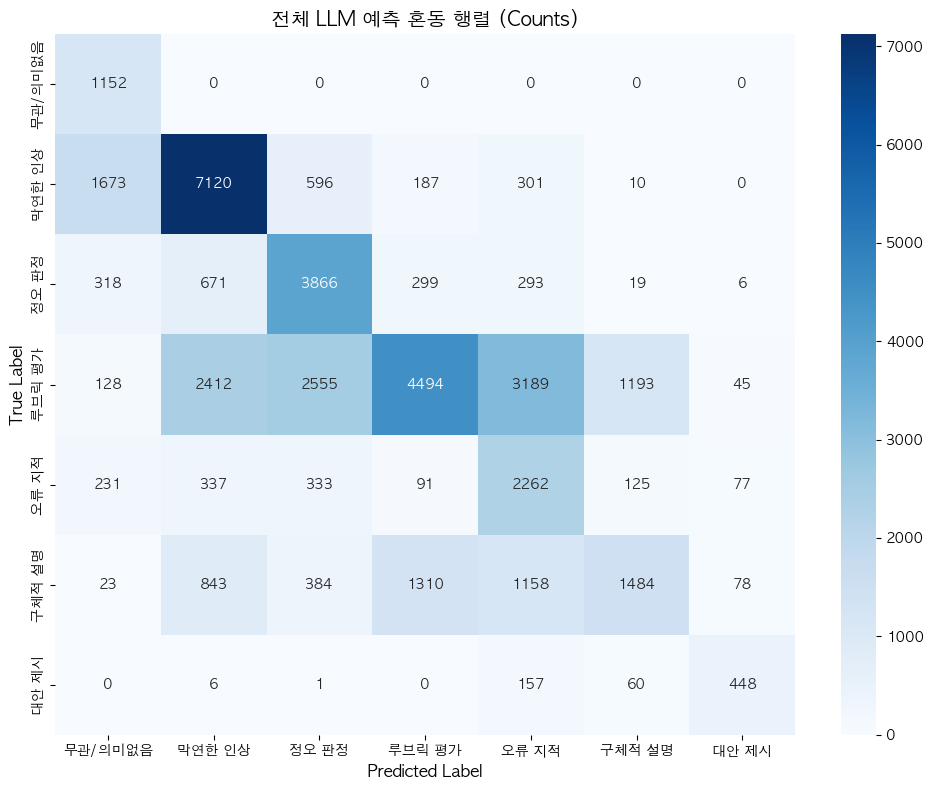

In [7]:
# 전체 혼동 행렬 (counts)
fig, cm_counts = plot_confusion_matrix(
    df_valid['y_true'], df_valid['y_pred'],
    title='전체 LLM 예측 혼동 행렬 (Counts)',
    label_names=LABEL_NAMES
)
plt.savefig('figures/llm_confusion_matrix_counts.png', dpi=150, bbox_inches='tight')
plt.show()

**결과 해석:**

혼동 행렬의 히트맵(heatmap)은 색이 진할수록 해당 셀의 값이 큰 것을 의미합니다.

- **대각선(정분류)**: Label 0(무관/의미없음)의 Recall이 1.00으로 가장 높아, LLM이 무관한 피드백은 완벽하게 식별합니다
- **비대각선(오분류)**: Label 3(루브릭 평가)에서 Label 4(오류 지적), Label 2(정오 판정), Label 1(막연한 인상)로의 오분류가 가장 빈번합니다
- **핵심 문제**: Label 3(루브릭 평가)은 Recall이 0.32로 매우 낮아, 실제 루브릭 평가 피드백의 68%를 다른 레이블로 잘못 분류합니다. 이는 한국어 피드백에서 "루브릭 평가"의 경계가 모호하기 때문입니다

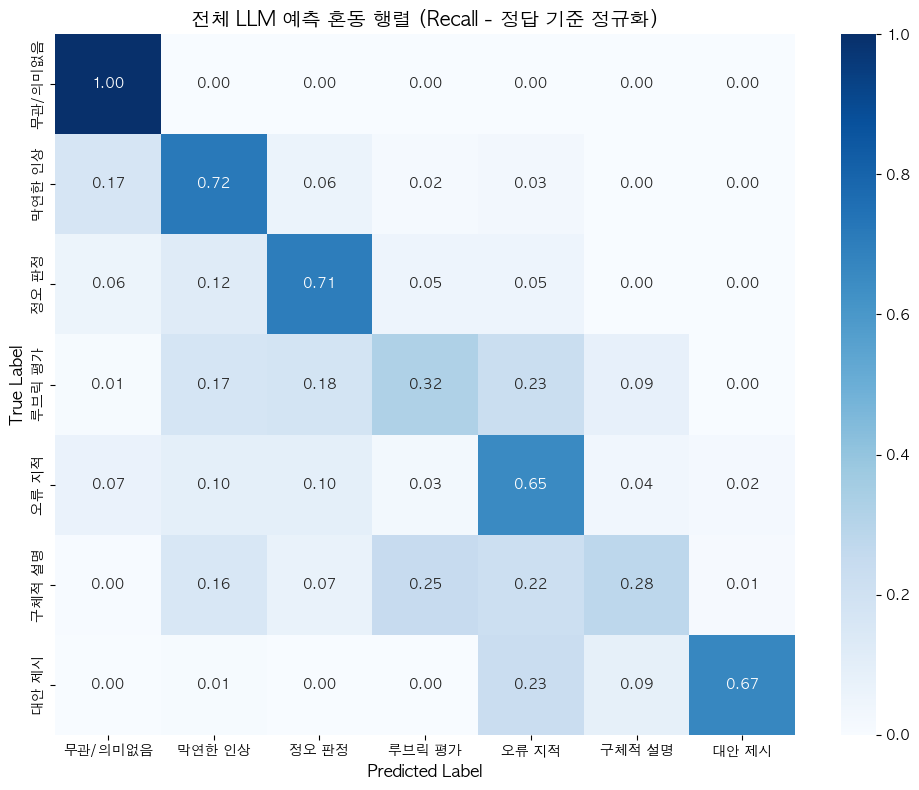

In [8]:
# 정규화된 혼동 행렬 (Recall 기준: 각 실제 레이블별로 예측이 어떻게 분포되었는지)
fig, cm_recall = plot_confusion_matrix(
    df_valid['y_true'], df_valid['y_pred'],
    title='전체 LLM 예측 혼동 행렬 (Recall - 정답 기준 정규화)',
    label_names=LABEL_NAMES,
    normalize='true'
)
plt.savefig('figures/llm_confusion_matrix_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 혼동 패턴 분석

In [9]:
def analyze_confusion_patterns(y_true, y_pred, labels=LABELS, label_names=LABEL_NAMES, top_n=10):
    """
    혼동 패턴 분석: 어떤 레이블 쌍에서 가장 많은 오류가 발생하는지
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # 오분류 패턴 추출 (대각선 제외)
    confusion_pairs = []
    for i, true_label in enumerate(labels):
        for j, pred_label in enumerate(labels):
            if i != j:  # 대각선(정분류) 제외
                count = cm[i, j]
                if count > 0:
                    confusion_pairs.append({
                        'true_label': true_label,
                        'pred_label': pred_label,
                        'true_name': label_names[true_label],
                        'pred_name': label_names[pred_label],
                        'count': count,
                        'pair': f"{true_label}→{pred_label}"
                    })
    
    df_confusion = pd.DataFrame(confusion_pairs)
    df_confusion = df_confusion.sort_values('count', ascending=False)
    
    return df_confusion

In [10]:
# 전체 혼동 패턴 분석
df_confusion_all = analyze_confusion_patterns(df_valid['y_true'], df_valid['y_pred'])

print("="*60)
print("가장 빈번한 오분류 패턴 (Top 15)")
print("="*60)
print(df_confusion_all.head(15).to_string(index=False))

가장 빈번한 오분류 패턴 (Top 15)
 true_label  pred_label true_name pred_name  count pair
          3           4    루브릭 평가     오류 지적   3189  3→4
          3           2    루브릭 평가     정오 판정   2555  3→2
          3           1    루브릭 평가    막연한 인상   2412  3→1
          1           0    막연한 인상   무관/의미없음   1673  1→0
          5           3    구체적 설명    루브릭 평가   1310  5→3
          3           5    루브릭 평가    구체적 설명   1193  3→5
          5           4    구체적 설명     오류 지적   1158  5→4
          5           1    구체적 설명    막연한 인상    843  5→1
          2           1     정오 판정    막연한 인상    671  2→1
          1           2    막연한 인상     정오 판정    596  1→2
          5           2    구체적 설명     정오 판정    384  5→2
          4           1     오류 지적    막연한 인상    337  4→1
          4           2     오류 지적     정오 판정    333  4→2
          2           0     정오 판정   무관/의미없음    318  2→0
          1           4    막연한 인상     오류 지적    301  1→4


**결과 해석:**

수평 막대 차트(Horizontal Bar Chart)는 가장 빈번한 오분류 패턴 15개를 보여줍니다.

- **1위**: 루브릭 평가 -> 오류 지적 (3,189건) - LLM이 "근거가 부족하다" 같은 루브릭 평가를 오류 지적으로 혼동
- **2위**: 루브릭 평가 -> 정오 판정 (2,555건) - "답과 근거 모두 맞음" 같은 표현을 단순 정오 판정으로 오분류
- **3위**: 루브릭 평가 -> 막연한 인상 (2,412건) - "잘했다" 등의 간결한 루브릭 평가를 막연한 인상으로 혼동
- **의미**: Label 3(루브릭 평가)이 한국어 피드백에서 가장 분류하기 어려운 범주임을 보여줍니다

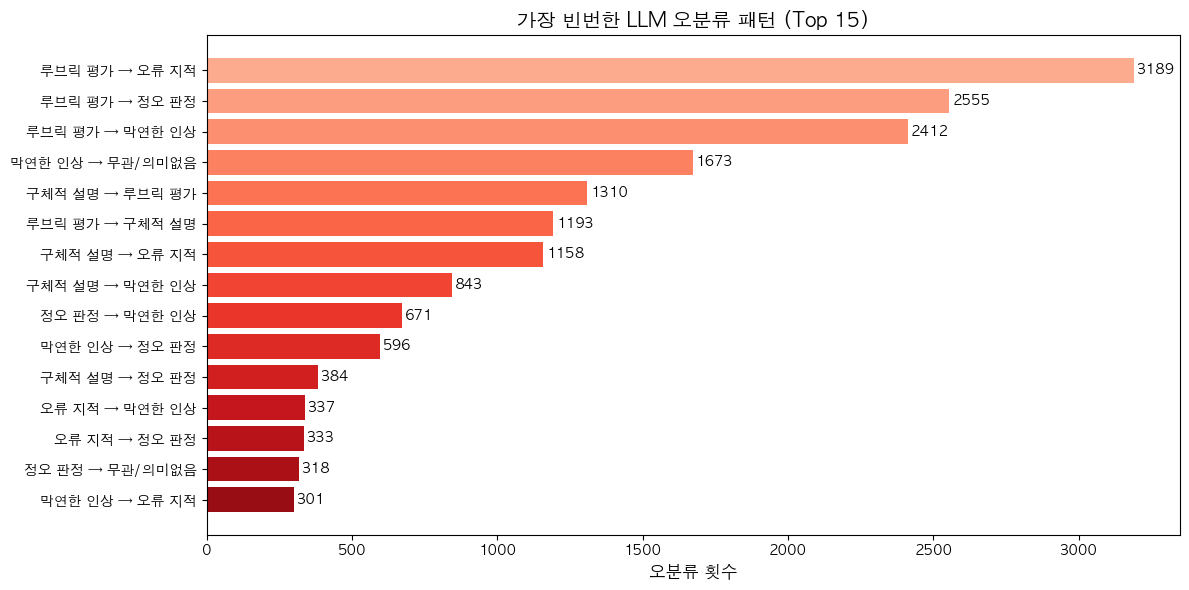

In [11]:
# 오분류 패턴 시각화
fig, ax = plt.subplots(figsize=(12, 6))

top_15 = df_confusion_all.head(15)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_15)))

bars = ax.barh(range(len(top_15)), top_15['count'], color=colors)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([f"{row['true_name']} → {row['pred_name']}" for _, row in top_15.iterrows()])
ax.invert_yaxis()
ax.set_xlabel('오분류 횟수', fontsize=12)
ax.set_title('가장 빈번한 LLM 오분류 패턴 (Top 15)', fontsize=14)

# 값 표시
for i, (bar, count) in enumerate(zip(bars, top_15['count'])):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
            str(count), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('figures/llm_top_confusion_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 레이블별 성능 분석

In [12]:
# Classification Report
print("="*60)
print("전체 분류 성능 리포트")
print("="*60)
print(classification_report(df_valid['y_true'], df_valid['y_pred'], 
                           labels=LABELS, 
                           target_names=[LABEL_NAMES[l] for l in LABELS],
                           digits=3))

전체 분류 성능 리포트
              precision    recall  f1-score   support

     무관/의미없음      0.327     1.000     0.493      1152
      막연한 인상      0.625     0.720     0.669      9887
       정오 판정      0.500     0.707     0.585      5472
      루브릭 평가      0.704     0.321     0.441     14016
       오류 지적      0.307     0.655     0.418      3456
      구체적 설명      0.513     0.281     0.363      5280
       대안 제시      0.685     0.667     0.676       672

    accuracy                          0.521     39935
   macro avg      0.523     0.621     0.521     39935
weighted avg      0.586     0.521     0.510     39935



**결과 해석:**

세 개의 막대 차트가 각 레이블의 Precision, Recall, F1-Score를 보여줍니다.

- **Label 0(무관/의미없음)**: Recall=1.00이지만 Precision=0.33 → LLM이 관련 있는 피드백도 무관으로 과다 예측하는 경향
- **Label 3(루브릭 평가)**: Precision=0.70이지만 Recall=0.32 → 실제 루브릭 평가의 대부분을 놓치고 있음
- **Label 5(구체적 설명)**: F1=0.36으로 가장 낮음 → LLM이 "구체적 설명"과 "루브릭 평가"를 구분하는 데 큰 어려움
- **Label 6(대안 제시)**: F1=0.68로 비교적 양호 → 대안 제시는 명확한 언어 패턴("~하면 좋겠다")이 있어 식별이 용이

In [13]:
# 레이블별 성능 시각화
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    df_valid['y_true'], df_valid['y_pred'], labels=LABELS
)

df_metrics = pd.DataFrame({
    'Label': LABELS,
    'Name': [LABEL_NAMES[l] for l in LABELS],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("레이블별 성능:")
print(df_metrics.to_string(index=False))

레이블별 성능:
 Label    Name  Precision   Recall  F1-Score  Support
     0 무관/의미없음   0.326809 1.000000  0.492623     1152
     1  막연한 인상   0.625165 0.720138  0.669299     9887
     2   정오 판정   0.499806 0.706506  0.585447     5472
     3  루브릭 평가   0.704278 0.320634  0.440653    14016
     4   오류 지적   0.307337 0.654514  0.418269     3456
     5  구체적 설명   0.513317 0.281061  0.363236     5280
     6   대안 제시   0.685015 0.666667  0.675716      672


**결과 해석:**

모델별 혼동 행렬(Recall 기반 정규화)을 비교합니다. 각 행의 합이 1.0이 되도록 정규화되어 있어, 실제 레이블별로 예측이 어떻게 분포되는지 보여줍니다.

- **GPT-4o**: Label 3(루브릭 평가)의 대각선 값이 Solar-Pro2보다 높아 상대적으로 양호하지만, Label 4(오류 지적)로의 오분류가 특히 많음
- **Solar-Pro2**: Label 3의 Recall이 극히 낮고, 다양한 레이블로 분산되어 오분류됨. 전반적으로 GPT-4o보다 혼동이 심함
- **공통점**: 두 모델 모두 Label 0(무관)은 완벽하게 식별하지만, Label 3과 Label 5에서 큰 어려움을 보임

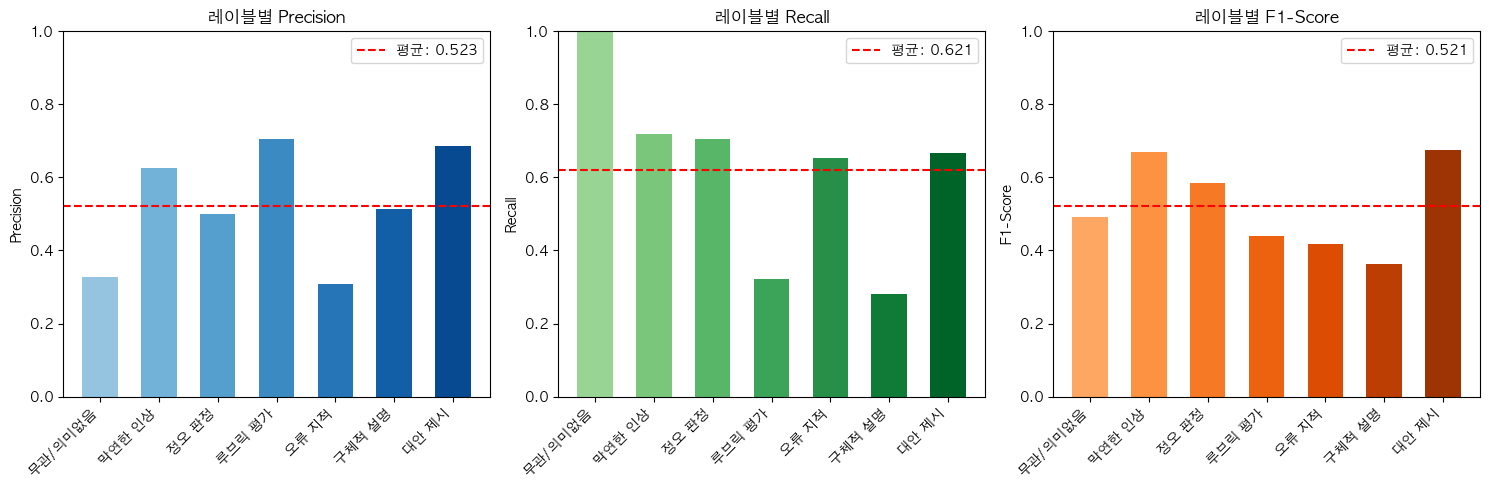

In [14]:
# 레이블별 Precision, Recall, F1 비교 그래프
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x = np.arange(len(LABELS))
width = 0.6

# Precision
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(LABELS)))
axes[0].bar(x, precision, width, color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels([LABEL_NAMES[l] for l in LABELS], rotation=45, ha='right')
axes[0].set_ylabel('Precision')
axes[0].set_title('레이블별 Precision')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=np.mean(precision), color='red', linestyle='--', label=f'평균: {np.mean(precision):.3f}')
axes[0].legend()

# Recall
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(LABELS)))
axes[1].bar(x, recall, width, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels([LABEL_NAMES[l] for l in LABELS], rotation=45, ha='right')
axes[1].set_ylabel('Recall')
axes[1].set_title('레이블별 Recall')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=np.mean(recall), color='red', linestyle='--', label=f'평균: {np.mean(recall):.3f}')
axes[1].legend()

# F1-Score
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(LABELS)))
axes[2].bar(x, f1, width, color=colors)
axes[2].set_xticks(x)
axes[2].set_xticklabels([LABEL_NAMES[l] for l in LABELS], rotation=45, ha='right')
axes[2].set_ylabel('F1-Score')
axes[2].set_title('레이블별 F1-Score')
axes[2].set_ylim(0, 1)
axes[2].axhline(y=np.mean(f1), color='red', linestyle='--', label=f'평균: {np.mean(f1):.3f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('figures/llm_label_performance.png', dpi=150, bbox_inches='tight')
plt.show()

**결과 해석:**

히트맵(Heatmap)은 모델별 각 레이블의 F1-Score를 색상으로 표현합니다. 녹색이 진할수록 높은 성능, 적색이 진할수록 낮은 성능입니다.

- GPT-4o가 대부분의 레이블에서 Solar-Pro2를 상회하며, 특히 Label 6(대안 제시)에서 큰 차이를 보임
- 두 모델 모두 Label 5(구체적 설명)에서 가장 어려움을 겪음 — 이 레이블은 다른 레이블과 의미적 경계가 불명확

## 5. 모델별 혼동 패턴 비교

모델 종류: ['solar-pro2' 'gpt-4o']


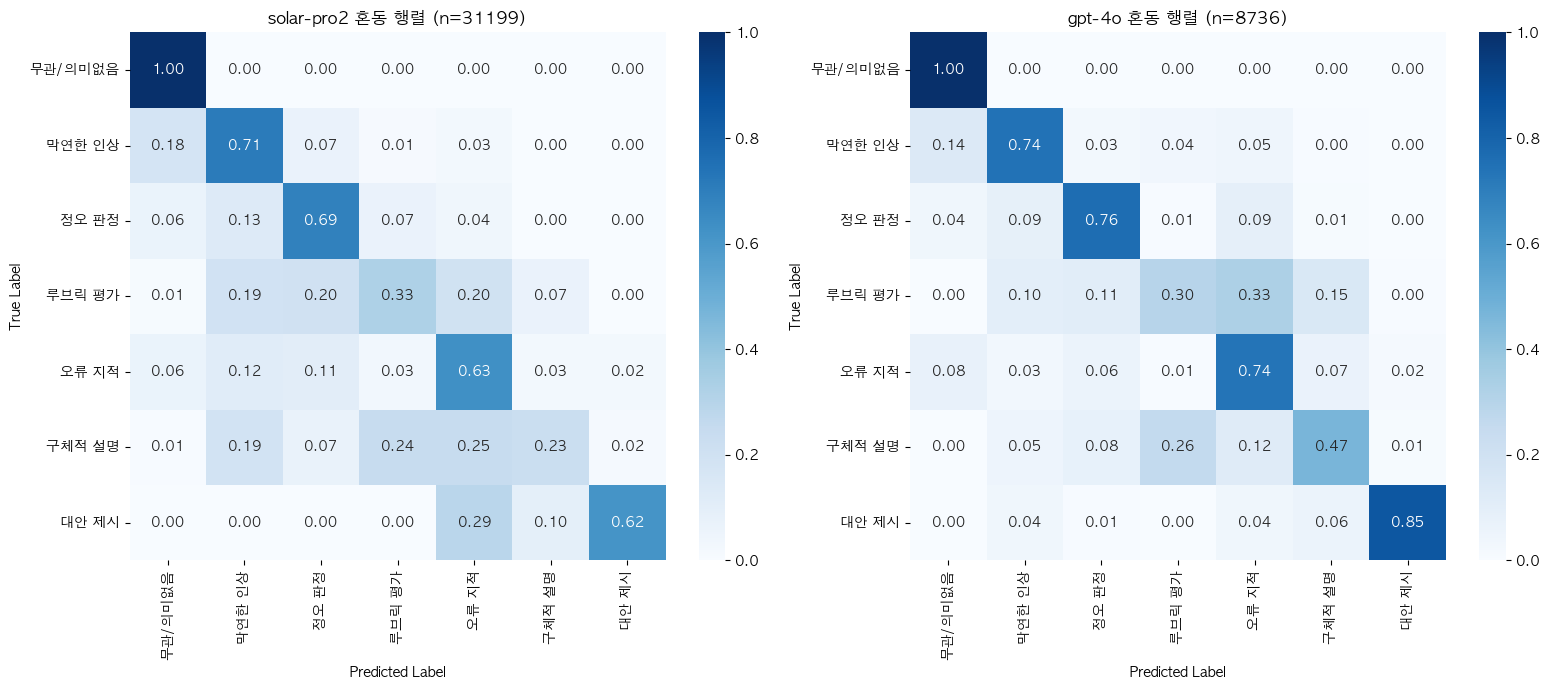

In [15]:
# 모델별 혼동 행렬 비교
models = df_valid['model'].unique()
print(f"모델 종류: {models}")

fig, axes = plt.subplots(1, len(models), figsize=(8*len(models), 7))
if len(models) == 1:
    axes = [axes]

for idx, model in enumerate(models):
    df_model = df_valid[df_valid['model'] == model]
    cm = confusion_matrix(df_model['y_true'], df_model['y_pred'], labels=LABELS, normalize='true')
    
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[LABEL_NAMES[l] for l in LABELS],
                yticklabels=[LABEL_NAMES[l] for l in LABELS],
                ax=axes[idx])
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_title(f'{model} 혼동 행렬 (n={len(df_model)})')

plt.tight_layout()
plt.savefig('figures/llm_confusion_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# 모델별 오분류 패턴 비교
for model in models:
    df_model = df_valid[df_valid['model'] == model]
    df_conf = analyze_confusion_patterns(df_model['y_true'], df_model['y_pred'])
    
    print(f"\n{'='*60}")
    print(f"{model} 주요 오분류 패턴 (Top 10)")
    print(f"{'='*60}")
    print(df_conf.head(10).to_string(index=False))


solar-pro2 주요 오분류 패턴 (Top 10)
 true_label  pred_label true_name pred_name  count pair
          3           2    루브릭 평가     정오 판정   2208  3→2
          3           4    루브릭 평가     오류 지적   2180  3→4
          3           1    루브릭 평가    막연한 인상   2106  3→1
          1           0    막연한 인상   무관/의미없음   1370  1→0
          5           4    구체적 설명     오류 지적   1014  5→4
          5           3    구체적 설명    루브릭 평가   1008  5→3
          5           1    구체적 설명    막연한 인상    781  5→1
          3           5    루브릭 평가    구체적 설명    731  3→5
          2           1     정오 판정    막연한 인상    567  2→1
          1           2    막연한 인상     정오 판정    539  1→2

gpt-4o 주요 오분류 패턴 (Top 10)
 true_label  pred_label true_name pred_name  count pair
          3           4    루브릭 평가     오류 지적   1009  3→4
          3           5    루브릭 평가    구체적 설명    462  3→5
          3           2    루브릭 평가     정오 판정    347  3→2
          3           1    루브릭 평가    막연한 인상    306  3→1
          1           0    막연한 인상   무관/의미없음   

모델별 레이블 성능 비교


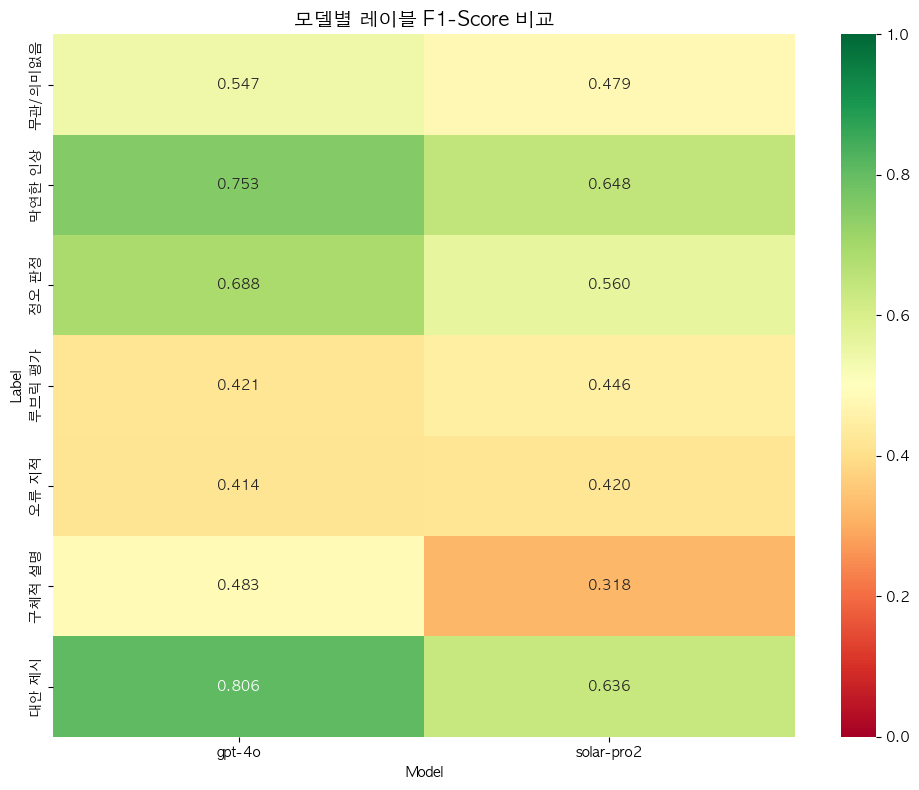


모델별 레이블 F1-Score:
Model         gpt-4o  solar-pro2
Label_Name                      
무관/의미없음     0.546638    0.479361
막연한 인상      0.752925    0.648277
정오 판정       0.688253    0.559568
루브릭 평가      0.421005    0.446026
오류 지적       0.414280    0.419589
구체적 설명      0.482820    0.318044
대안 제시       0.806452    0.635827


In [17]:
# 모델별 레이블 성능 비교
print("="*80)
print("모델별 레이블 성능 비교")
print("="*80)

model_label_metrics = []
for model in models:
    df_model = df_valid[df_valid['model'] == model]
    prec, rec, f1, sup = precision_recall_fscore_support(
        df_model['y_true'], df_model['y_pred'], labels=LABELS, zero_division=0
    )
    for l in LABELS:
        model_label_metrics.append({
            'Model': model,
            'Label': l,
            'Label_Name': LABEL_NAMES[l],
            'Precision': prec[l],
            'Recall': rec[l],
            'F1-Score': f1[l],
            'Support': sup[l]
        })

df_model_label = pd.DataFrame(model_label_metrics)

# 모델별 레이블 F1-Score 히트맵
pivot_f1 = df_model_label.pivot(index='Label_Name', columns='Model', values='F1-Score')
pivot_f1 = pivot_f1.reindex([LABEL_NAMES[l] for l in LABELS])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax)
ax.set_title('모델별 레이블 F1-Score 비교', fontsize=14)
ax.set_xlabel('Model')
ax.set_ylabel('Label')
plt.tight_layout()
plt.savefig('figures/llm_model_label_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n모델별 레이블 F1-Score:")
print(pivot_f1.to_string())

## 6. 프롬프트 버전별 혼동 패턴 비교

프롬프트별 레이블 성능 비교


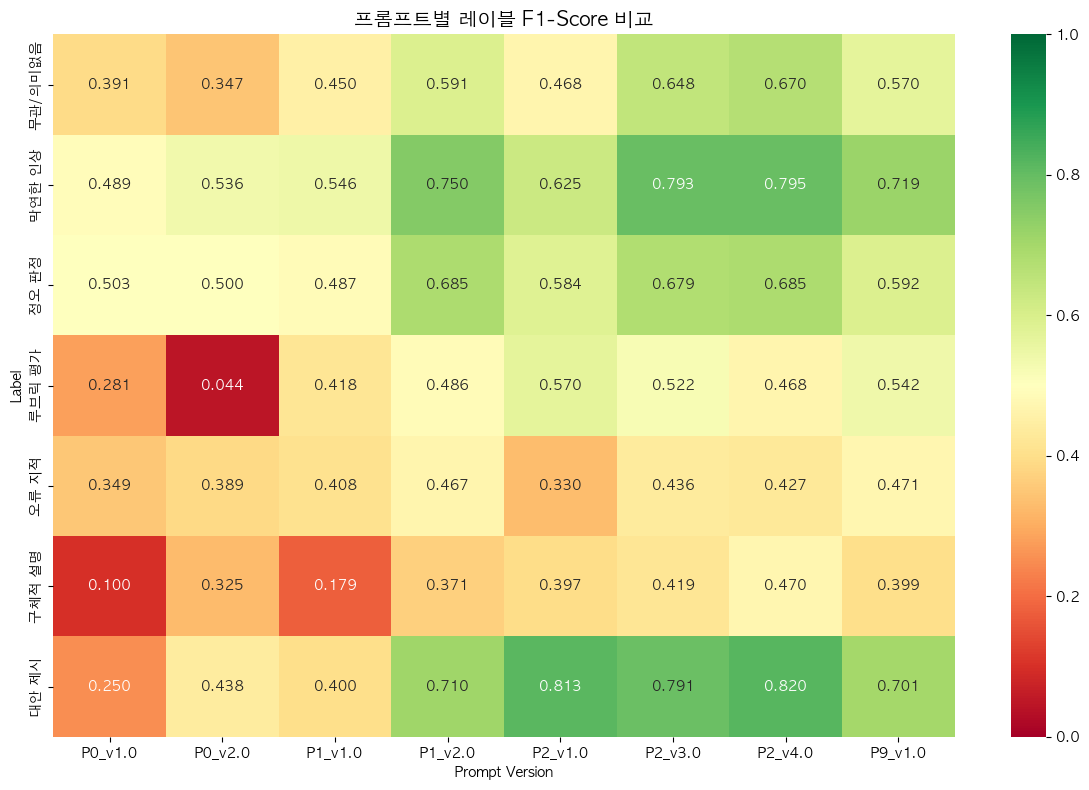


프롬프트별 레이블 F1-Score:
Prompt       P0_v1.0   P0_v2.0   P1_v1.0   P1_v2.0   P2_v1.0   P2_v3.0   P2_v4.0   P9_v1.0
Label_Name                                                                                
무관/의미없음     0.391304  0.346709  0.450000  0.591376  0.467532  0.647676  0.669767  0.569921
막연한 인상      0.489083  0.536213  0.546448  0.750098  0.625092  0.793328  0.795312  0.718698
정오 판정       0.502773  0.500494  0.486708  0.684673  0.584299  0.679108  0.684892  0.591699
루브릭 평가      0.281139  0.044348  0.418462  0.485636  0.569647  0.522471  0.467802  0.542143
오류 지적       0.348993  0.388590  0.407583  0.467428  0.329670  0.436123  0.426877  0.471453
구체적 설명      0.100000  0.325246  0.178571  0.371025  0.396552  0.418902  0.469595  0.398734
대안 제시       0.250000  0.437811  0.400000  0.709677  0.813187  0.791367  0.820000  0.701107


In [18]:
# 프롬프트 버전 정의
prompt_versions = sorted(df_valid['prompt_version'].unique())

# 프롬프트별 레이블 성능 비교
print("="*80)
print("프롬프트별 레이블 성능 비교")
print("="*80)

prompt_label_metrics = []
for prompt_ver in prompt_versions:
    df_prompt = df_valid[df_valid['prompt_version'] == prompt_ver]
    prec, rec, f1, sup = precision_recall_fscore_support(
        df_prompt['y_true'], df_prompt['y_pred'], labels=LABELS, zero_division=0
    )
    for l in LABELS:
        prompt_label_metrics.append({
            'Prompt': prompt_ver,
            'Label': l,
            'Label_Name': LABEL_NAMES[l],
            'Precision': prec[l],
            'Recall': rec[l],
            'F1-Score': f1[l],
            'Support': sup[l]
        })

df_prompt_label = pd.DataFrame(prompt_label_metrics)

# 프롬프트별 레이블 F1-Score 히트맵
pivot_prompt_f1 = df_prompt_label.pivot(index='Label_Name', columns='Prompt', values='F1-Score')
pivot_prompt_f1 = pivot_prompt_f1.reindex([LABEL_NAMES[l] for l in LABELS])

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_prompt_f1, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax)
ax.set_title('프롬프트별 레이블 F1-Score 비교', fontsize=14)
ax.set_xlabel('Prompt Version')
ax.set_ylabel('Label')
plt.tight_layout()
plt.savefig('figures/llm_prompt_label_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n프롬프트별 레이블 F1-Score:")
print(pivot_prompt_f1.to_string())

**결과 해석:**

모델x프롬프트 조합별 Kappa와 Macro F1 히트맵입니다.

- **GPT-4o + P2_v4.0**(few-shot CoT v4)이 가장 높은 Kappa(0.554)와 F1(0.662)을 달성
- **P0(제로샷 루브릭 기반)** 프롬프트가 가장 낮은 성능 → 예시 없이 루브릭만 제시하면 LLM의 분류가 부정확
- **프롬프트 효과**: P2(few-shot + Chain-of-Thought) 계열이 일관되게 P0(제로샷)보다 우수 → 예시와 사고 과정 안내가 LLM 분류 정확도 향상에 핵심

프롬프트 버전: ['P0_v1.0', 'P0_v2.0', 'P1_v1.0', 'P1_v2.0', 'P2_v1.0', 'P2_v3.0', 'P2_v4.0', 'P9_v1.0']


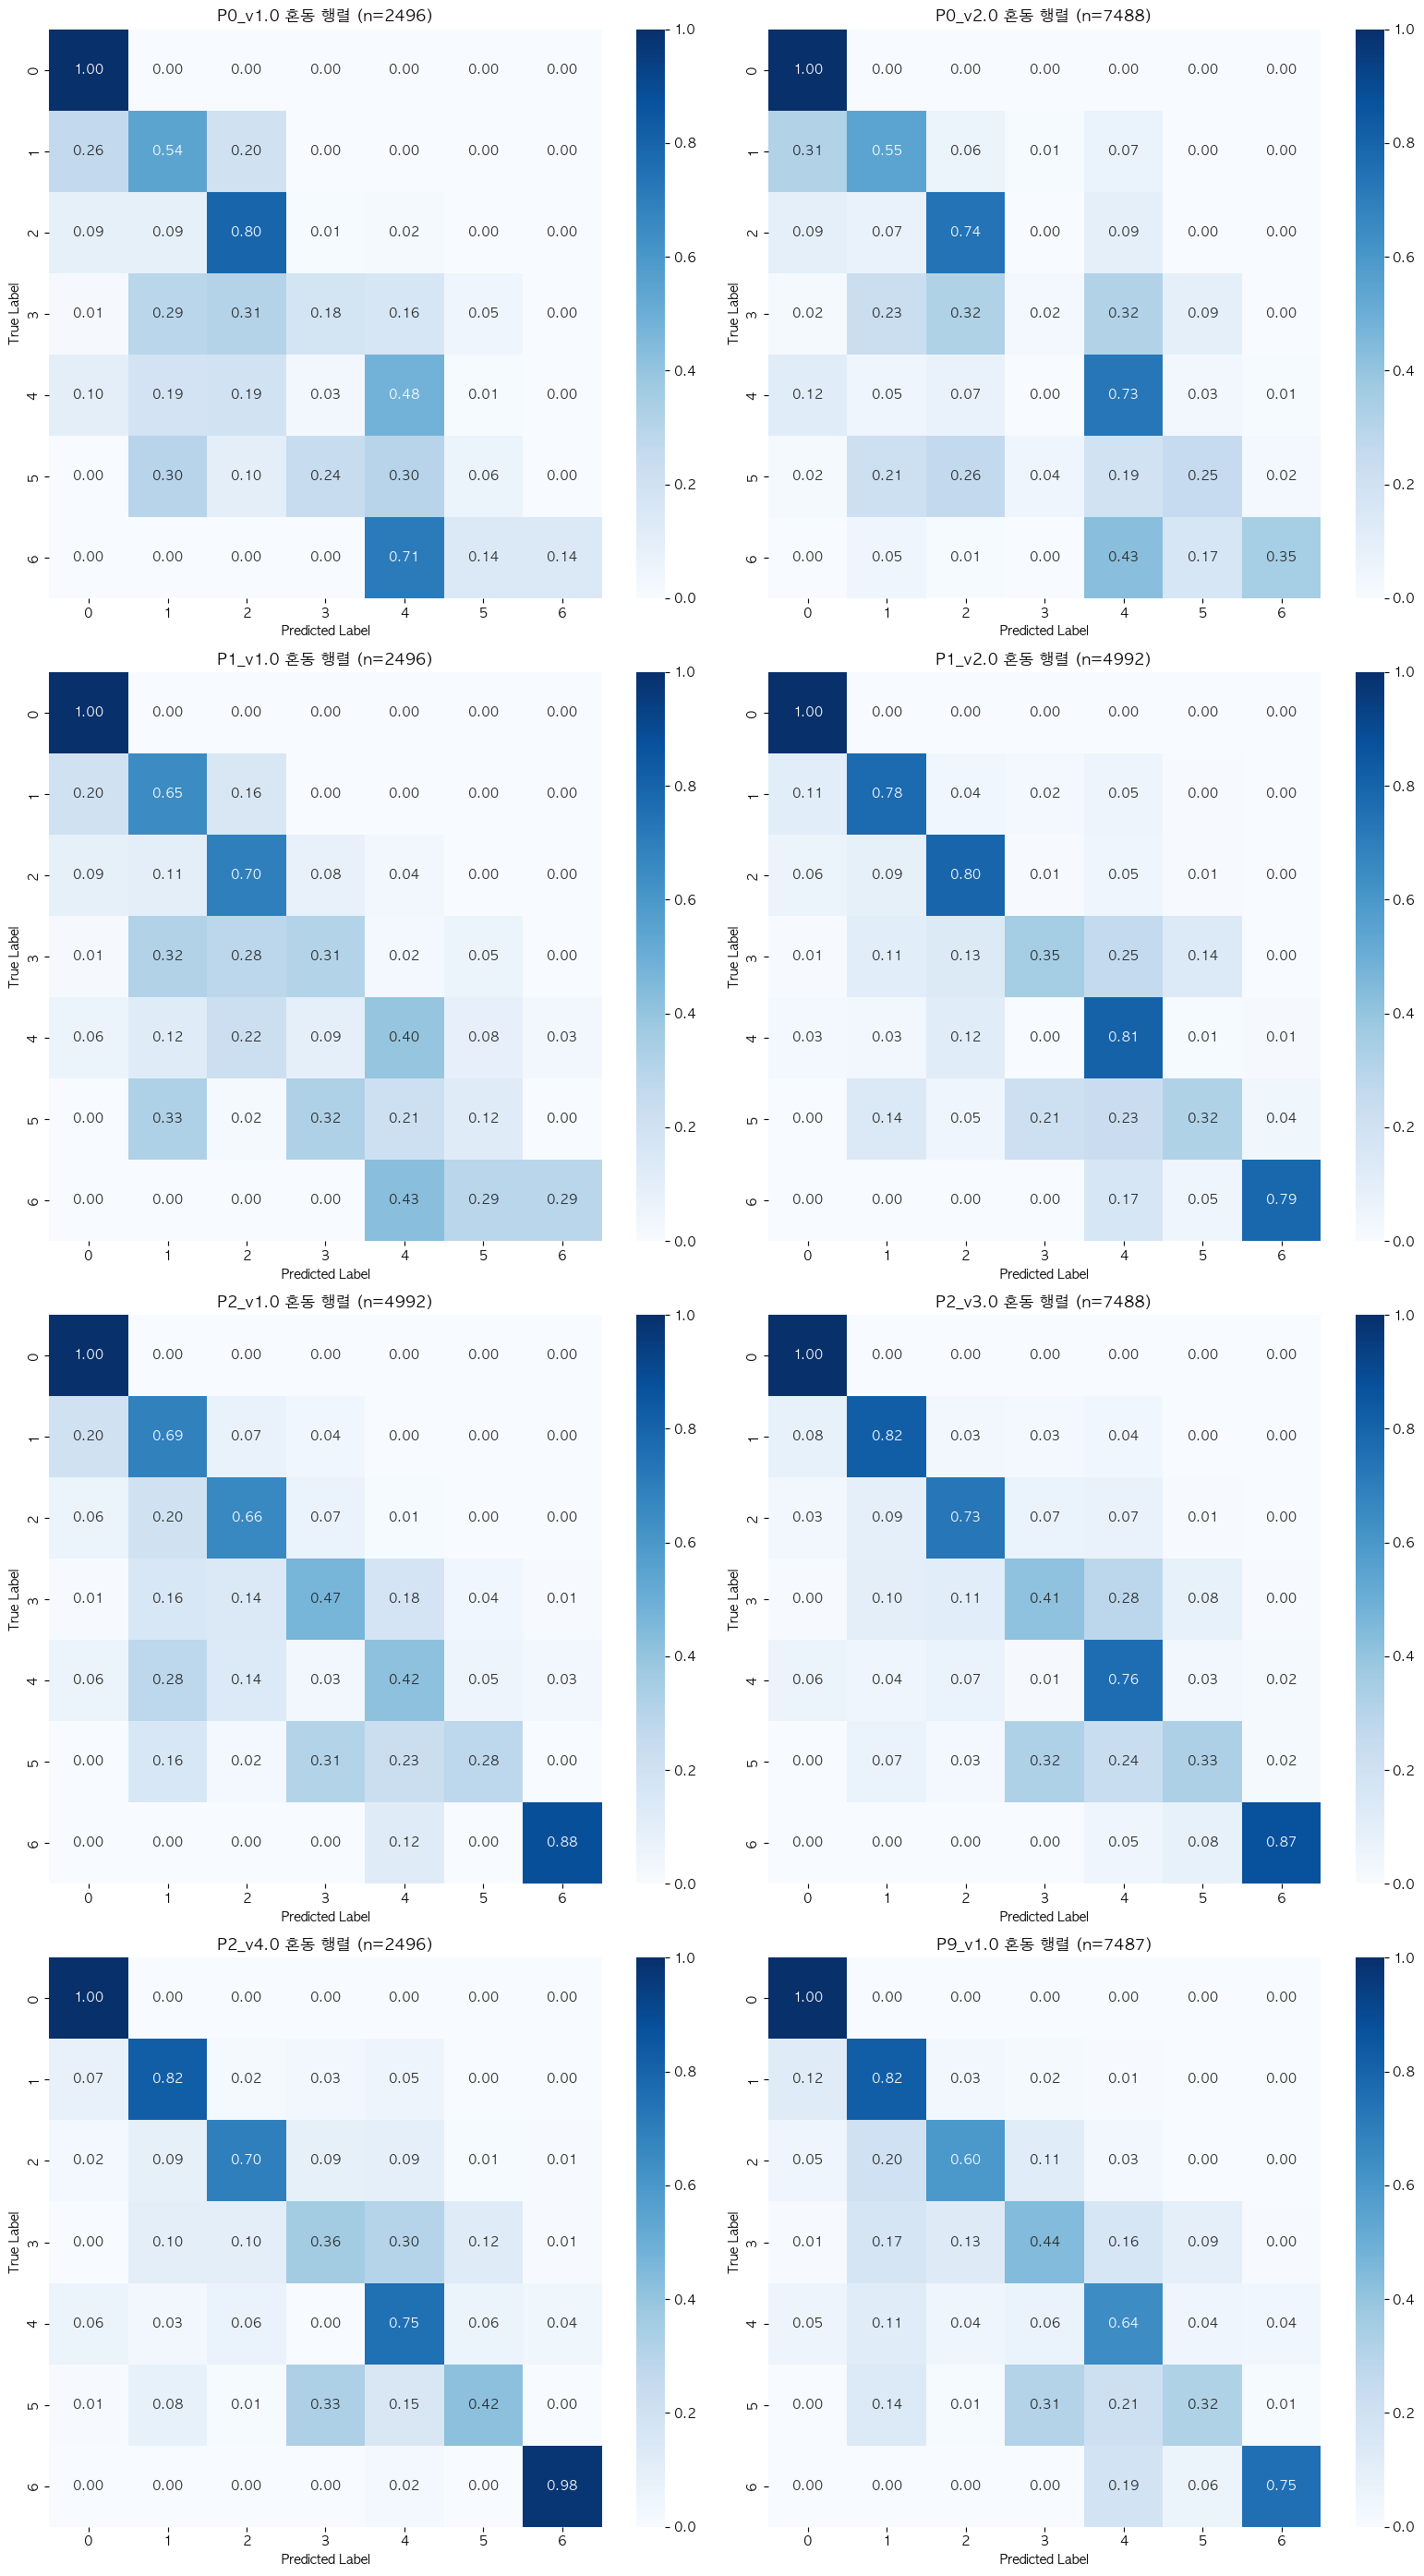

In [19]:
# 프롬프트 버전별 혼동 행렬
prompt_versions = sorted(df_valid['prompt_version'].unique())
print(f"프롬프트 버전: {prompt_versions}")

n_cols = min(2, len(prompt_versions))
n_rows = (len(prompt_versions) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 7*n_rows))
if len(prompt_versions) == 1:
    axes = np.array([[axes]])
axes = axes.flatten() if len(prompt_versions) > 1 else [axes]

for idx, prompt_ver in enumerate(prompt_versions):
    df_prompt = df_valid[df_valid['prompt_version'] == prompt_ver]
    cm = confusion_matrix(df_prompt['y_true'], df_prompt['y_pred'], labels=LABELS, normalize='true')
    
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABELS,
                yticklabels=LABELS,
                ax=axes[idx])
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_title(f'{prompt_ver} 혼동 행렬 (n={len(df_prompt)})')

# 빈 subplot 숨기기
for idx in range(len(prompt_versions), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('figures/llm_confusion_by_prompt.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 모델 × 프롬프트 조합별 분석

In [20]:
# 모델 × 프롬프트 조합 생성
df_valid['model_prompt'] = df_valid['model'] + ' + ' + df_valid['prompt_version']
combinations = sorted(df_valid['model_prompt'].unique())
print(f"모델×프롬프트 조합 수: {len(combinations)}")
for combo in combinations:
    n = len(df_valid[df_valid['model_prompt'] == combo])
    print(f"  - {combo}: {n:,} samples")

모델×프롬프트 조합 수: 13
  - gpt-4o + P0_v2.0: 2,496 samples
  - gpt-4o + P1_v2.0: 1,248 samples
  - gpt-4o + P2_v3.0: 2,496 samples
  - gpt-4o + P2_v4.0: 1,248 samples
  - gpt-4o + P9_v1.0: 1,248 samples
  - solar-pro2 + P0_v1.0: 2,496 samples
  - solar-pro2 + P0_v2.0: 4,992 samples
  - solar-pro2 + P1_v1.0: 2,496 samples
  - solar-pro2 + P1_v2.0: 3,744 samples
  - solar-pro2 + P2_v1.0: 4,992 samples
  - solar-pro2 + P2_v3.0: 4,992 samples
  - solar-pro2 + P2_v4.0: 1,248 samples
  - solar-pro2 + P9_v1.0: 6,239 samples


In [21]:
# 조합별 전체 성능 매트릭스
from sklearn.metrics import accuracy_score, cohen_kappa_score

combo_metrics = []
for combo in combinations:
    df_combo = df_valid[df_valid['model_prompt'] == combo]
    model = df_combo['model'].iloc[0]
    prompt = df_combo['prompt_version'].iloc[0]
    
    acc = accuracy_score(df_combo['y_true'], df_combo['y_pred'])
    kappa = cohen_kappa_score(df_combo['y_true'], df_combo['y_pred'])
    prec, rec, f1, _ = precision_recall_fscore_support(
        df_combo['y_true'], df_combo['y_pred'], average='macro', zero_division=0
    )
    
    combo_metrics.append({
        'Model': model,
        'Prompt': prompt,
        'Combination': combo,
        'Accuracy': acc,
        'Kappa': kappa,
        'Macro_F1': f1,
        'Macro_Precision': prec,
        'Macro_Recall': rec,
        'N_Samples': len(df_combo)
    })

df_combo_metrics = pd.DataFrame(combo_metrics)

print("="*80)
print("모델 × 프롬프트 조합별 전체 성능")
print("="*80)
print(df_combo_metrics.to_string(index=False))

모델 × 프롬프트 조합별 전체 성능
     Model  Prompt          Combination  Accuracy    Kappa  Macro_F1  Macro_Precision  Macro_Recall  N_Samples
    gpt-4o P0_v2.0     gpt-4o + P0_v2.0  0.439103 0.343011  0.455560         0.474535      0.594028       2496
    gpt-4o P1_v2.0     gpt-4o + P1_v2.0  0.608173 0.519845  0.653412         0.628147      0.744182       1248
    gpt-4o P2_v3.0     gpt-4o + P2_v3.0  0.625000 0.538181  0.669133         0.650632      0.745649       2496
    gpt-4o P2_v4.0     gpt-4o + P2_v4.0  0.637019 0.554332  0.662052         0.635264      0.754828       1248
    gpt-4o P9_v1.0     gpt-4o + P9_v1.0  0.568910 0.476014  0.563016         0.547236      0.685315       1248
solar-pro2 P0_v1.0 solar-pro2 + P0_v1.0  0.387821 0.261695  0.337613         0.464536      0.457760       2496
solar-pro2 P0_v2.0 solar-pro2 + P0_v2.0  0.344752 0.239710  0.319855         0.388605      0.482569       4992
solar-pro2 P1_v1.0 solar-pro2 + P1_v1.0  0.448718 0.315320  0.412539         0.457426      0

**결과 해석:**

혼동 네트워크(Confusion Network)는 레이블 간 혼동 관계를 원형 네트워크로 시각화합니다. 선이 굵을수록 두 레이블 간 혼동이 잦음을 의미합니다.

- **가장 굵은 연결**: Label 3(루브릭 평가) ↔ Label 4(오류 지적) = 3,280회 혼동
- **중심 노드**: Label 3이 가장 많은 연결을 가져, LLM 혼동의 핵심 원인임을 시각적으로 확인
- **의미**: 한국어 동료 피드백에서 "루브릭 평가"와 "오류 지적"의 언어적 경계가 모호하여 LLM이 구분하기 어려움 (예: "근거가 부족하다"는 루브릭 평가인지 오류 지적인지 맥락에 따라 달라짐)

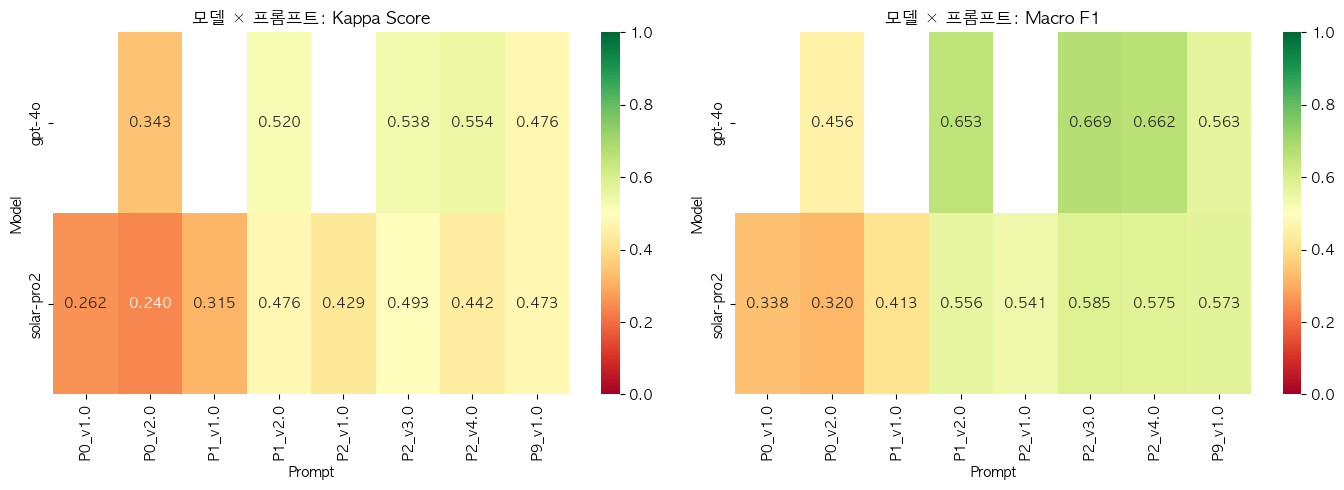

In [22]:
# 조합별 성능 히트맵 (Kappa & Macro F1)
pivot_kappa = df_combo_metrics.pivot(index='Model', columns='Prompt', values='Kappa')
pivot_macro_f1 = df_combo_metrics.pivot(index='Model', columns='Prompt', values='Macro_F1')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kappa 히트맵
sns.heatmap(pivot_kappa, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('모델 × 프롬프트: Kappa Score', fontsize=12)

# Macro F1 히트맵
sns.heatmap(pivot_macro_f1, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('모델 × 프롬프트: Macro F1', fontsize=12)

plt.tight_layout()
plt.savefig('figures/llm_model_prompt_performance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# 조합별 레이블 성능 상세 분석
print("="*80)
print("모델 × 프롬프트 조합별 레이블 성능 (F1-Score)")
print("="*80)

combo_label_metrics = []
for combo in combinations:
    df_combo = df_valid[df_valid['model_prompt'] == combo]
    model = df_combo['model'].iloc[0]
    prompt = df_combo['prompt_version'].iloc[0]
    
    prec, rec, f1, sup = precision_recall_fscore_support(
        df_combo['y_true'], df_combo['y_pred'], labels=LABELS, zero_division=0
    )
    
    for l in LABELS:
        combo_label_metrics.append({
            'Model': model,
            'Prompt': prompt,
            'Combination': combo,
            'Label': l,
            'Label_Name': LABEL_NAMES[l],
            'Precision': prec[l],
            'Recall': rec[l],
            'F1-Score': f1[l],
            'Support': sup[l]
        })

df_combo_label = pd.DataFrame(combo_label_metrics)

# 조합별 레이블 F1 출력
for combo in combinations:
    df_c = df_combo_label[df_combo_label['Combination'] == combo]
    print(f"\n[{combo}]")
    print(df_c[['Label', 'Label_Name', 'F1-Score', 'Precision', 'Recall']].to_string(index=False))

모델 × 프롬프트 조합별 레이블 성능 (F1-Score)

[gpt-4o + P0_v2.0]
 Label Label_Name  F1-Score  Precision   Recall
     0    무관/의미없음  0.410256   0.258065 1.000000
     1     막연한 인상  0.641418   0.638844 0.644013
     2      정오 판정  0.564162   0.466539 0.713450
     3     루브릭 평가  0.098664   0.494845 0.054795
     4      오류 지적  0.384615   0.259740 0.740741
     5     구체적 설명  0.459665   0.461774 0.457576
     6      대안 제시  0.630137   0.741935 0.547619

[gpt-4o + P1_v2.0]
 Label Label_Name  F1-Score  Precision   Recall
     0    무관/의미없음  0.720000   0.562500 1.000000
     1     막연한 인상  0.772727   0.775244 0.770227
     2      정오 판정  0.765217   0.758621 0.771930
     3     루브릭 평가  0.494012   0.717391 0.376712
     4      오류 지적  0.459103   0.321033 0.805556
     5     구체적 설명  0.469208   0.454545 0.484848
     6      대안 제시  0.893617   0.807692 1.000000

[gpt-4o + P2_v3.0]
 Label Label_Name  F1-Score  Precision   Recall
     0    무관/의미없음  0.742268   0.590164 1.000000
     1     막연한 인상  0.821630   0.819646 0.823

In [24]:
# 각 레이블별 최고/최저 성능 조합 찾기
print("="*80)
print("레이블별 최고/최저 성능 조합")
print("="*80)

for l in LABELS:
    df_l = df_combo_label[df_combo_label['Label'] == l]
    best = df_l.loc[df_l['F1-Score'].idxmax()]
    worst = df_l.loc[df_l['F1-Score'].idxmin()]
    
    print(f"\n[Label {l}: {LABEL_NAMES[l]}]")
    print(f"  최고: {best['Combination']} (F1={best['F1-Score']:.3f})")
    print(f"  최저: {worst['Combination']} (F1={worst['F1-Score']:.3f})")
    print(f"  차이: {best['F1-Score'] - worst['F1-Score']:.3f}")

레이블별 최고/최저 성능 조합

[Label 0: 무관/의미없음]
  최고: gpt-4o + P2_v3.0 (F1=0.742)
  최저: solar-pro2 + P0_v2.0 (F1=0.322)
  차이: 0.420

[Label 1: 막연한 인상]
  최고: gpt-4o + P2_v4.0 (F1=0.848)
  최저: solar-pro2 + P0_v2.0 (F1=0.485)
  차이: 0.363

[Label 2: 정오 판정]
  최고: gpt-4o + P2_v4.0 (F1=0.775)
  최저: solar-pro2 + P0_v2.0 (F1=0.475)
  차이: 0.299

[Label 3: 루브릭 평가]
  최고: solar-pro2 + P2_v1.0 (F1=0.570)
  최저: solar-pro2 + P0_v2.0 (F1=0.015)
  차이: 0.555

[Label 4: 오류 지적]
  최고: solar-pro2 + P9_v1.0 (F1=0.485)
  최저: solar-pro2 + P2_v1.0 (F1=0.330)
  차이: 0.156

[Label 5: 구체적 설명]
  최고: gpt-4o + P2_v4.0 (F1=0.528)
  최저: solar-pro2 + P0_v1.0 (F1=0.100)
  차이: 0.428

[Label 6: 대안 제시]
  최고: gpt-4o + P2_v3.0 (F1=0.933)
  최저: solar-pro2 + P0_v1.0 (F1=0.250)
  차이: 0.683


## 8. 혼동이 심한 레이블 쌍 심층 분석

In [25]:
# 양방향 혼동 분석 (A→B와 B→A를 함께 분석)
def analyze_bidirectional_confusion(df_confusion):
    """양방향 혼동 패턴 분석"""
    pairs = {}
    for _, row in df_confusion.iterrows():
        key = tuple(sorted([row['true_label'], row['pred_label']]))
        if key not in pairs:
            pairs[key] = {'A→B': 0, 'B→A': 0, 'total': 0, 'labels': key}
        
        if row['true_label'] < row['pred_label']:
            pairs[key]['A→B'] = row['count']
        else:
            pairs[key]['B→A'] = row['count']
        pairs[key]['total'] += row['count']
    
    df_pairs = pd.DataFrame(pairs.values())
    df_pairs = df_pairs.sort_values('total', ascending=False)
    return df_pairs

df_bidirectional = analyze_bidirectional_confusion(df_confusion_all)

print("="*70)
print("양방향 혼동 패턴 분석 (가장 혼동이 심한 레이블 쌍)")
print("="*70)

for _, row in df_bidirectional.head(10).iterrows():
    l1, l2 = row['labels']
    print(f"\n[{LABEL_NAMES[l1]}] ↔ [{LABEL_NAMES[l2]}]")
    print(f"  총 혼동: {row['total']}회")
    print(f"  {l1}→{l2}: {row['A→B']}회 | {l2}→{l1}: {row['B→A']}회")

양방향 혼동 패턴 분석 (가장 혼동이 심한 레이블 쌍)

[루브릭 평가] ↔ [오류 지적]
  총 혼동: 3280회
  3→4: 3189회 | 4→3: 91회

[정오 판정] ↔ [루브릭 평가]
  총 혼동: 2854회
  2→3: 299회 | 3→2: 2555회

[막연한 인상] ↔ [루브릭 평가]
  총 혼동: 2599회
  1→3: 187회 | 3→1: 2412회

[루브릭 평가] ↔ [구체적 설명]
  총 혼동: 2503회
  3→5: 1193회 | 5→3: 1310회

[무관/의미없음] ↔ [막연한 인상]
  총 혼동: 1673회
  0→1: 0회 | 1→0: 1673회

[오류 지적] ↔ [구체적 설명]
  총 혼동: 1283회
  4→5: 125회 | 5→4: 1158회

[막연한 인상] ↔ [정오 판정]
  총 혼동: 1267회
  1→2: 596회 | 2→1: 671회

[막연한 인상] ↔ [구체적 설명]
  총 혼동: 853회
  1→5: 10회 | 5→1: 843회

[막연한 인상] ↔ [오류 지적]
  총 혼동: 638회
  1→4: 301회 | 4→1: 337회

[정오 판정] ↔ [오류 지적]
  총 혼동: 626회
  2→4: 293회 | 4→2: 333회


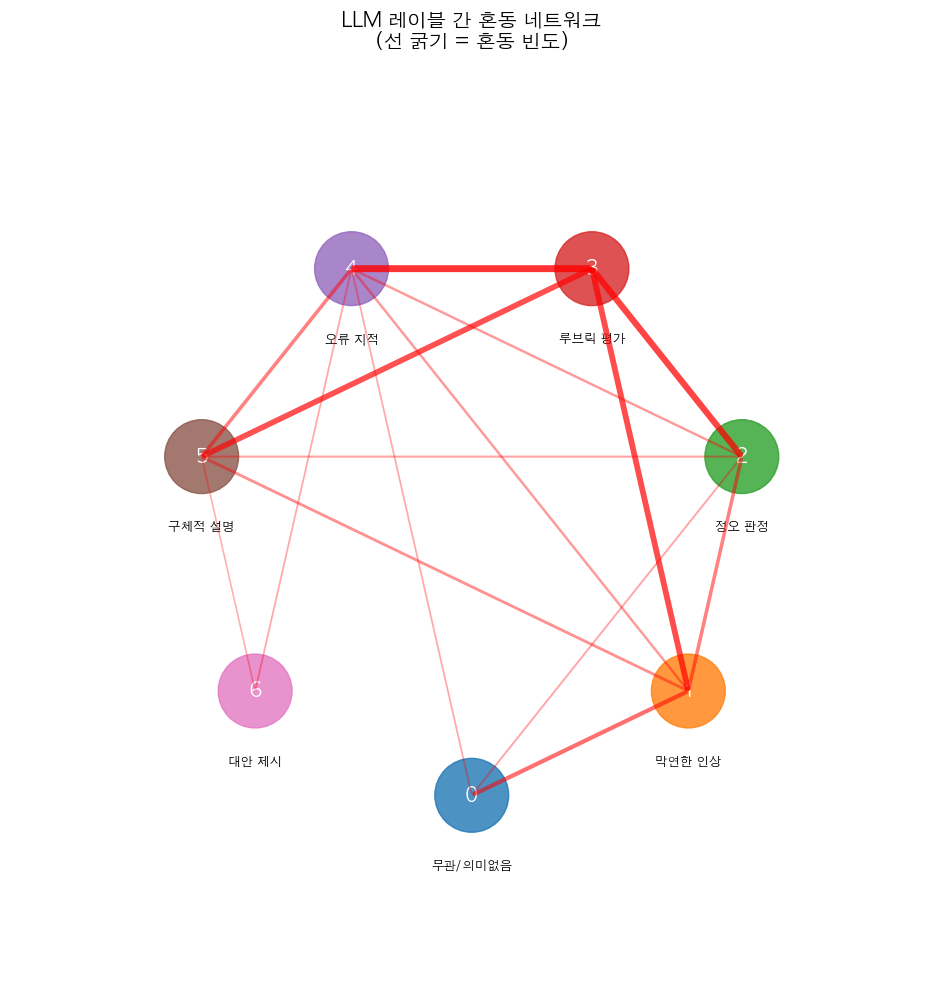

In [26]:
# 혼동이 심한 레이블 쌍 네트워크 시각화
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 10))

# 원형 배치
n_labels = len(LABELS)
angles = np.linspace(0, 2*np.pi, n_labels, endpoint=False)
radius = 3

pos = {l: (radius * np.cos(angles[l] - np.pi/2), radius * np.sin(angles[l] - np.pi/2)) 
       for l in LABELS}

# 노드 그리기
for l in LABELS:
    circle = plt.Circle(pos[l], 0.4, color=plt.cm.tab10(l), alpha=0.8)
    ax.add_patch(circle)
    ax.text(pos[l][0], pos[l][1], str(l), ha='center', va='center', 
            fontsize=14, fontweight='bold', color='white')
    ax.text(pos[l][0], pos[l][1] - 0.7, LABEL_NAMES[l], ha='center', va='top', fontsize=9)

# 혼동 엣지 그리기 (상위 15개)
top_confusions = df_bidirectional.head(15)
max_count = top_confusions['total'].max()

for _, row in top_confusions.iterrows():
    l1, l2 = row['labels']
    width = 1 + 4 * (row['total'] / max_count)
    alpha = 0.3 + 0.5 * (row['total'] / max_count)
    
    ax.annotate('', xy=pos[l2], xytext=pos[l1],
                arrowprops=dict(arrowstyle='-', color='red', alpha=alpha, lw=width))

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('LLM 레이블 간 혼동 네트워크\n(선 굵기 = 혼동 빈도)', fontsize=14)

plt.tight_layout()
plt.savefig('figures/llm_confusion_network.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 모델/프롬프트별 양방향 혼동 분석 및 네트워크 시각화

In [27]:
# 모델별 양방향 혼동 분석
print("="*80)
print("모델별 양방향 혼동 패턴 비교")
print("="*80)

model_bidir_data = {}
for model in models:
    df_model = df_valid[df_valid['model'] == model]
    df_conf = analyze_confusion_patterns(df_model['y_true'], df_model['y_pred'])
    df_bidir = analyze_bidirectional_confusion(df_conf)
    model_bidir_data[model] = df_bidir
    
    print(f"\n[{model}] Top 5 양방향 혼동 패턴:")
    for _, row in df_bidir.head(5).iterrows():
        l1, l2 = row['labels']
        print(f"  {LABEL_NAMES[l1]} ↔ {LABEL_NAMES[l2]}: {row['total']}회 ({l1}→{l2}: {row['A→B']} | {l2}→{l1}: {row['B→A']})")

모델별 양방향 혼동 패턴 비교

[solar-pro2] Top 5 양방향 혼동 패턴:
  정오 판정 ↔ 루브릭 평가: 2498회 (2→3: 290 | 3→2: 2208)
  루브릭 평가 ↔ 오류 지적: 2267회 (3→4: 2180 | 4→3: 87)
  막연한 인상 ↔ 루브릭 평가: 2216회 (1→3: 110 | 3→1: 2106)
  루브릭 평가 ↔ 구체적 설명: 1739회 (3→5: 731 | 5→3: 1008)
  무관/의미없음 ↔ 막연한 인상: 1370회 (0→1: 0 | 1→0: 1370)

[gpt-4o] Top 5 양방향 혼동 패턴:
  루브릭 평가 ↔ 오류 지적: 1013회 (3→4: 1009 | 4→3: 4)
  루브릭 평가 ↔ 구체적 설명: 764회 (3→5: 462 | 5→3: 302)
  막연한 인상 ↔ 루브릭 평가: 383회 (1→3: 77 | 3→1: 306)
  정오 판정 ↔ 루브릭 평가: 356회 (2→3: 9 | 3→2: 347)
  무관/의미없음 ↔ 막연한 인상: 303회 (0→1: 0 | 1→0: 303)


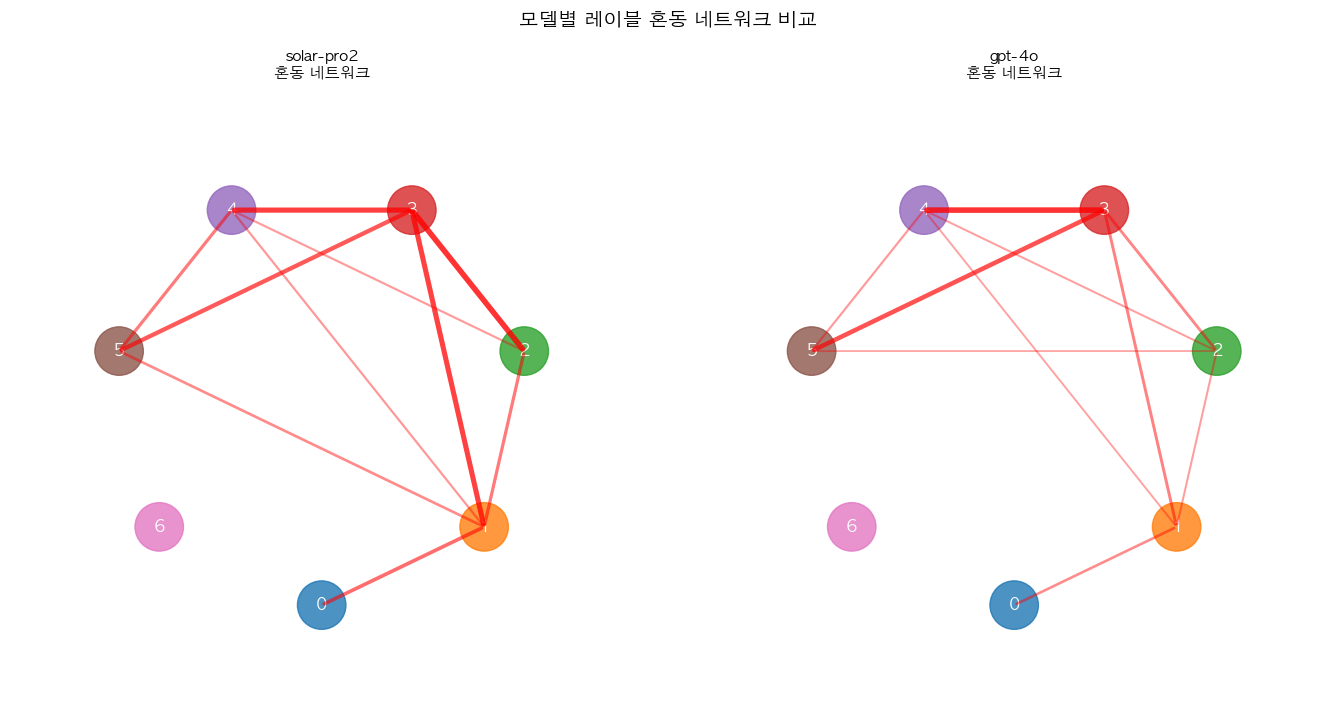

In [28]:
# 모델별 혼동 네트워크 시각화
def plot_confusion_network(df_bidir, title, ax, top_n=10):
    """양방향 혼동 네트워크 시각화"""
    n_labels = len(LABELS)
    angles = np.linspace(0, 2*np.pi, n_labels, endpoint=False)
    radius = 3
    pos = {l: (radius * np.cos(angles[l] - np.pi/2), radius * np.sin(angles[l] - np.pi/2)) 
           for l in LABELS}
    
    # 노드 그리기
    for l in LABELS:
        circle = plt.Circle(pos[l], 0.35, color=plt.cm.tab10(l), alpha=0.8)
        ax.add_patch(circle)
        ax.text(pos[l][0], pos[l][1], str(l), ha='center', va='center', 
                fontsize=12, fontweight='bold', color='white')
    
    # 혼동 엣지 그리기
    if len(df_bidir) > 0:
        top_conf = df_bidir.head(top_n)
        max_count = top_conf['total'].max() if top_conf['total'].max() > 0 else 1
        
        for _, row in top_conf.iterrows():
            l1, l2 = row['labels']
            width = 1 + 3 * (row['total'] / max_count)
            alpha = 0.3 + 0.5 * (row['total'] / max_count)
            ax.annotate('', xy=pos[l2], xytext=pos[l1],
                        arrowprops=dict(arrowstyle='-', color='red', alpha=alpha, lw=width))
    
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11)

# 모델별 네트워크 비교
fig, axes = plt.subplots(1, len(models), figsize=(7*len(models), 7))
if len(models) == 1:
    axes = [axes]

for idx, model in enumerate(models):
    plot_confusion_network(model_bidir_data[model], f'{model}\n혼동 네트워크', axes[idx])

plt.suptitle('모델별 레이블 혼동 네트워크 비교', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/llm_confusion_network_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

모델×프롬프트 조합별 양방향 혼동 패턴

[gpt-4o + P0_v2.0] Top 3 양방향 혼동:
  루브릭 평가 ↔ 오류 지적: 327회
  루브릭 평가 ↔ 구체적 설명: 189회
  정오 판정 ↔ 루브릭 평가: 187회

[gpt-4o + P1_v2.0] Top 3 양방향 혼동:
  루브릭 평가 ↔ 구체적 설명: 126회
  루브릭 평가 ↔ 오류 지적: 125회
  막연한 인상 ↔ 루브릭 평가: 58회

[gpt-4o + P2_v3.0] Top 3 양방향 혼동:
  루브릭 평가 ↔ 오류 지적: 293회
  루브릭 평가 ↔ 구체적 설명: 222회
  막연한 인상 ↔ 루브릭 평가: 89회

[gpt-4o + P2_v4.0] Top 3 양방향 혼동:
  루브릭 평가 ↔ 오류 지적: 137회
  루브릭 평가 ↔ 구체적 설명: 122회
  막연한 인상 ↔ 루브릭 평가: 32회

[gpt-4o + P9_v1.0] Top 3 양방향 혼동:
  루브릭 평가 ↔ 오류 지적: 131회
  루브릭 평가 ↔ 구체적 설명: 105회
  무관/의미없음 ↔ 막연한 인상: 72회

[solar-pro2 + P0_v1.0] Top 3 양방향 혼동:
  정오 판정 ↔ 루브릭 평가: 274회
  막연한 인상 ↔ 루브릭 평가: 252회
  무관/의미없음 ↔ 막연한 인상: 160회

[solar-pro2 + P0_v2.0] Top 3 양방향 혼동:
  정오 판정 ↔ 루브릭 평가: 651회
  루브릭 평가 ↔ 오류 지적: 505회
  막연한 인상 ↔ 루브릭 평가: 449회

[solar-pro2 + P1_v1.0] Top 3 양방향 혼동:
  막연한 인상 ↔ 루브릭 평가: 276회
  정오 판정 ↔ 루브릭 평가: 274회
  루브릭 평가 ↔ 구체적 설명: 154회

[solar-pro2 + P1_v2.0] Top 3 양방향 혼동:
  루브릭 평가 ↔ 오류 지적: 320회
  루브릭 평가 ↔ 구체적 설명: 257회
  정오 판정 ↔ 루브릭 평가: 213회

[solar-pro2 + P2_v1.0

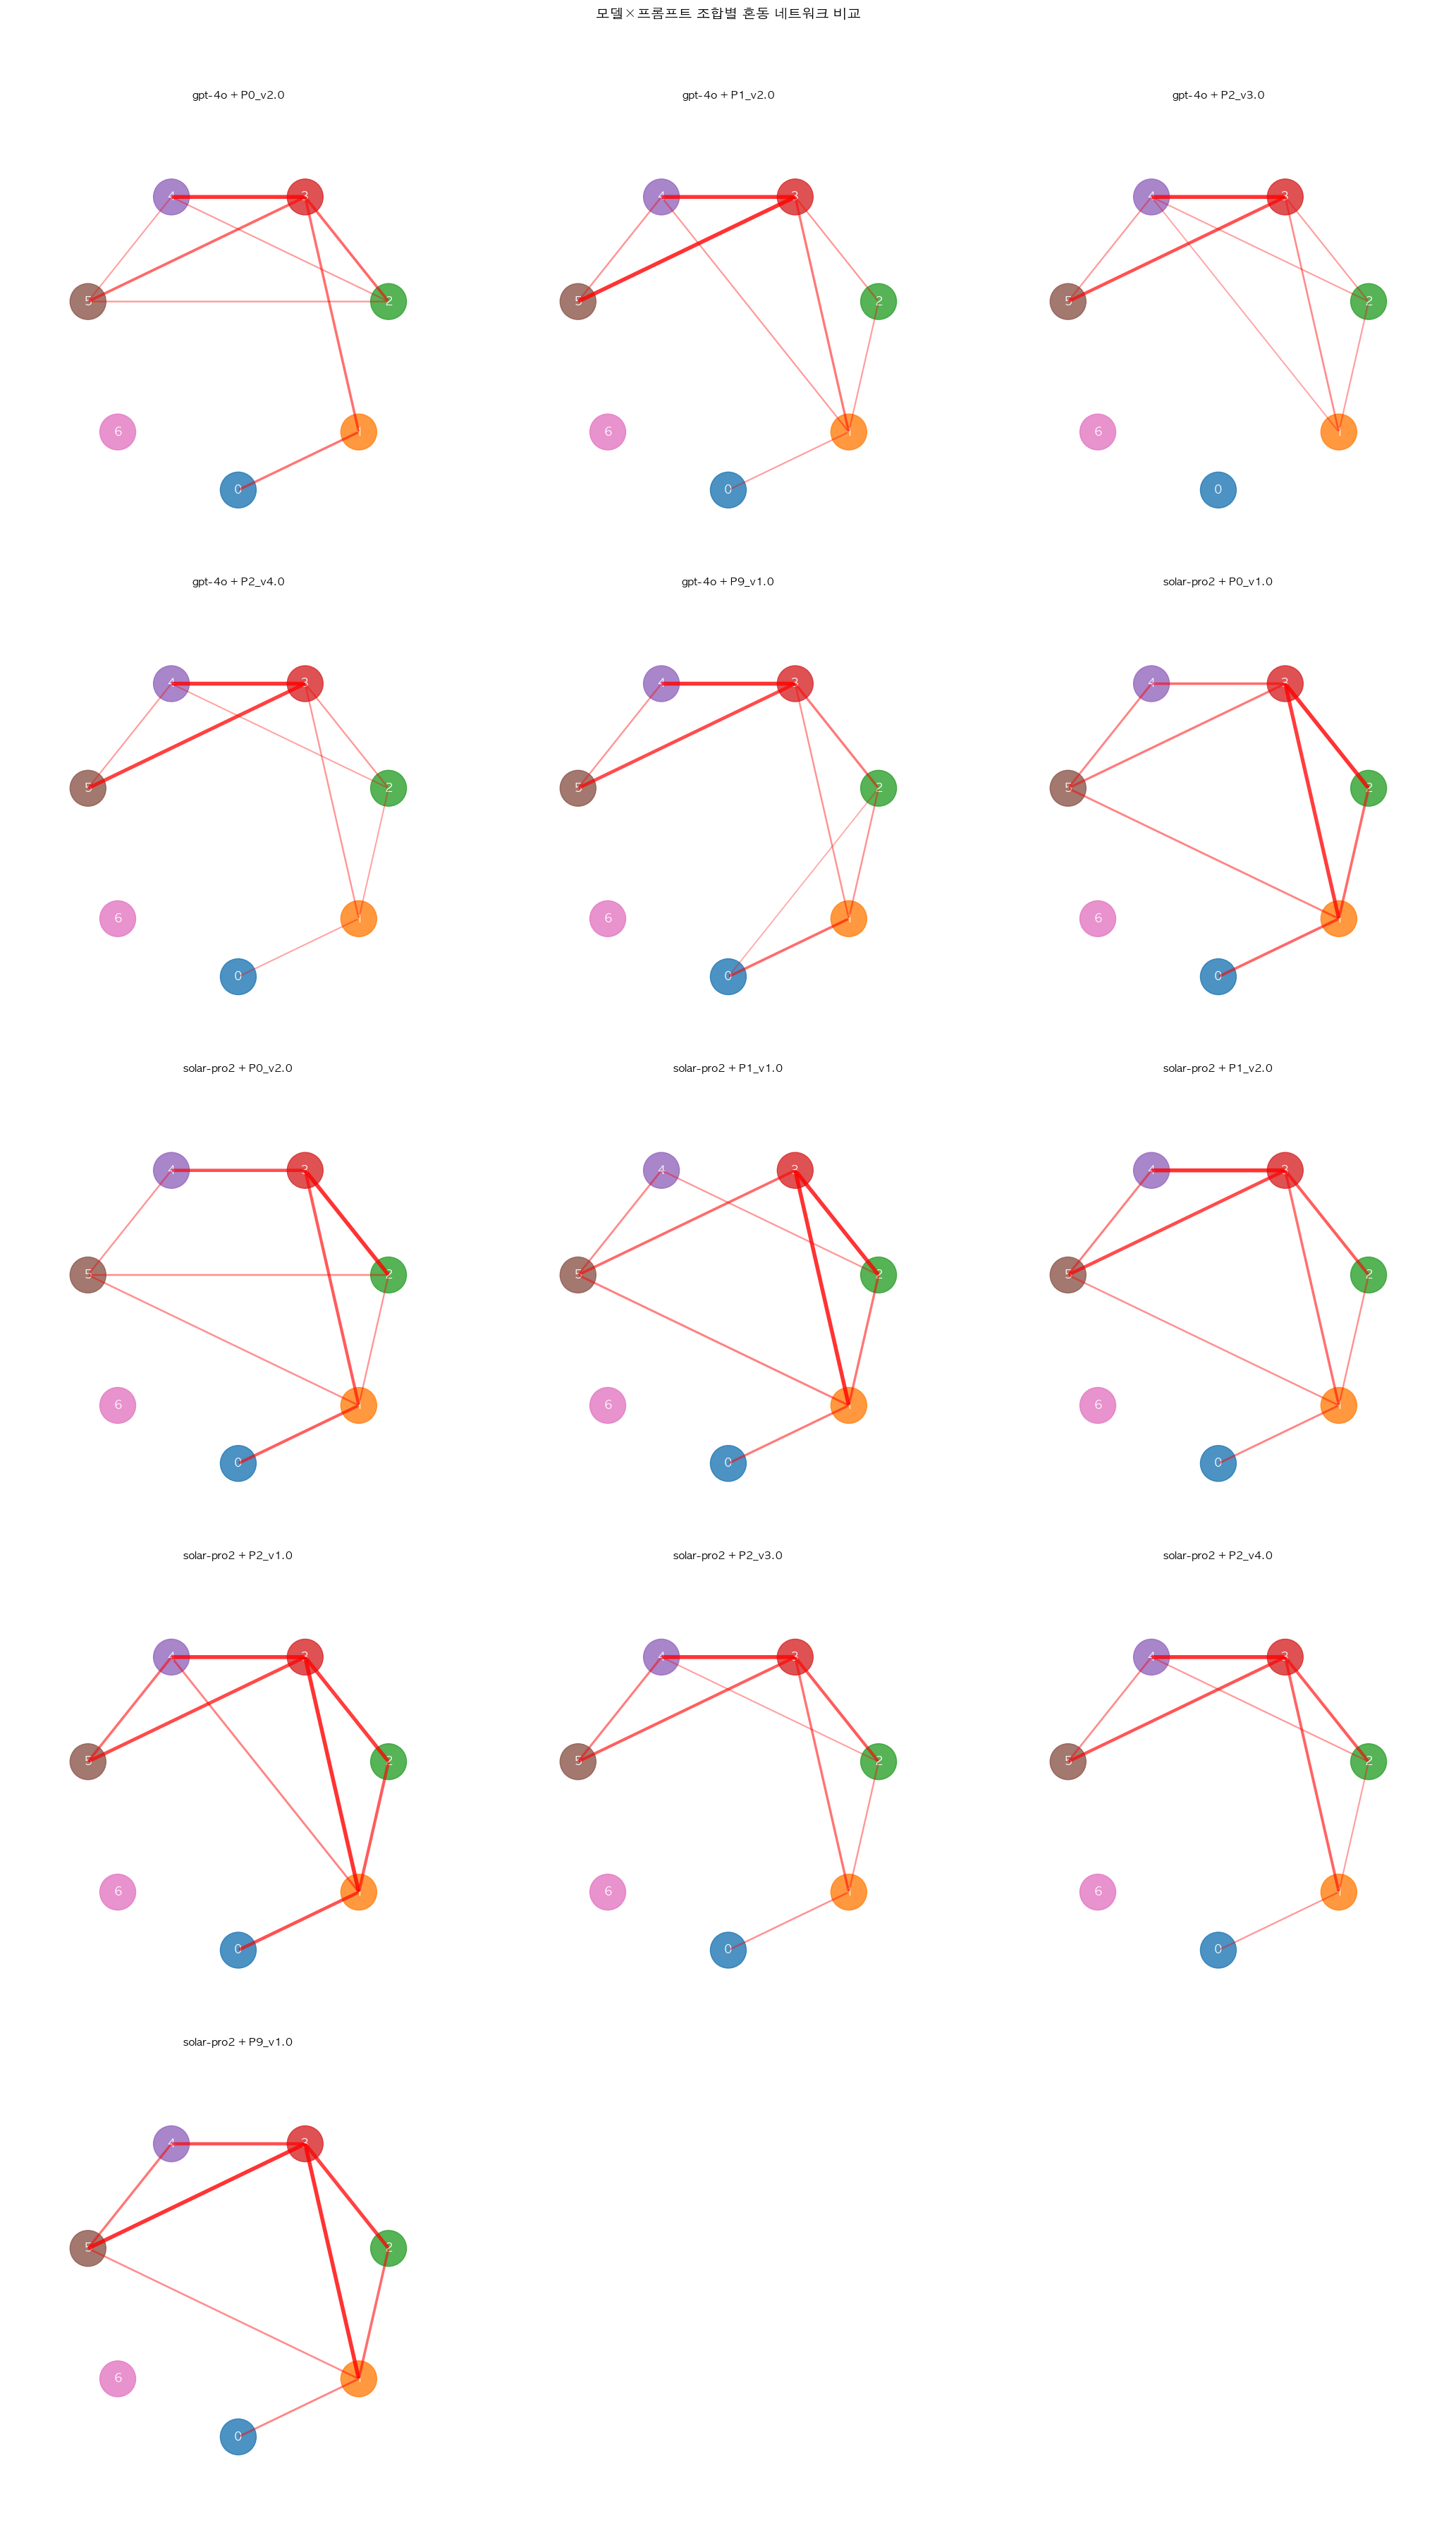

In [29]:
# 모델×프롬프트 조합별 양방향 혼동 분석 및 네트워크 시각화
print("="*80)
print("모델×프롬프트 조합별 양방향 혼동 패턴")
print("="*80)

combo_bidir_data = {}
for combo in combinations:
    df_combo = df_valid[df_valid['model_prompt'] == combo]
    df_conf = analyze_confusion_patterns(df_combo['y_true'], df_combo['y_pred'])
    df_bidir = analyze_bidirectional_confusion(df_conf)
    combo_bidir_data[combo] = df_bidir
    
    print(f"\n[{combo}] Top 3 양방향 혼동:")
    for _, row in df_bidir.head(3).iterrows():
        l1, l2 = row['labels']
        print(f"  {LABEL_NAMES[l1]} ↔ {LABEL_NAMES[l2]}: {row['total']}회")

# 조합별 혼동 네트워크 시각화
n_combos = len(combinations)
n_cols = min(3, n_combos)
n_rows = (n_combos + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 7*n_rows))
axes = axes.flatten() if n_combos > 1 else [axes]

for idx, combo in enumerate(combinations):
    plot_confusion_network(combo_bidir_data[combo], f'{combo}', axes[idx], top_n=8)

# 빈 subplot 숨기기
for idx in range(n_combos, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('모델×프롬프트 조합별 혼동 네트워크 비교', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/llm_confusion_network_by_combo.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 결과 요약

In [ ]:
# 결과 요약 출력
print("="*70)
print("LLM 혼동 행렬 분석 결과 요약")
print("="*70)

print(f"\n[데이터 개요]")
print(f"  - 총 예측 수: {len(df_valid):,}")
print(f"  - 모델: {', '.join(models)}")
print(f"  - 프롬프트 버전: {', '.join(prompt_versions)}")

print(f"\n[가장 어려운 레이블 (낮은 F1-Score)]")
df_sorted = df_metrics.sort_values('F1-Score')
for _, row in df_sorted.head(3).iterrows():
    print(f"  - Label {row['Label']} ({row['Name']}): F1={row['F1-Score']:.3f}, Precision={row['Precision']:.3f}, Recall={row['Recall']:.3f}")

print(f"\n[가장 빈번한 오분류 패턴]")
for _, row in df_confusion_all.head(5).iterrows():
    print(f"  - {row['true_name']} → {row['pred_name']}: {row['count']:,}회")

print(f"\n[가장 혼동이 심한 레이블 쌍]")
for _, row in df_bidirectional.head(3).iterrows():
    l1, l2 = row['labels']
    print(f"  - [{LABEL_NAMES[l1]}] ↔ [{LABEL_NAMES[l2]}]: 총 {row['total']:,}회 혼동")

In [ ]:
# 결과 CSV로 저장
Path('results').mkdir(exist_ok=True)

# 레이블별 성능
df_metrics.to_csv('results/llm_label_performance.csv', index=False)
print("저장됨: results/llm_label_performance.csv")

# 혼동 패턴
df_confusion_all.to_csv('results/llm_confusion_patterns.csv', index=False)
print("저장됨: results/llm_confusion_patterns.csv")

# 양방향 혼동
df_bidirectional.to_csv('results/llm_bidirectional_confusion.csv', index=False)
print("저장됨: results/llm_bidirectional_confusion.csv")

In [ ]:
# figures 폴더 생성 확인
Path('figures').mkdir(exist_ok=True)
print("\n생성된 시각화 파일:")
for f in Path('figures').glob('llm_*.png'):
    print(f"  - {f}")